<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/phase1-foundations/day07_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import shutil

# Option 1: Download directly from URL (no Kaggle account needed)
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv",
    "titanic.csv"
)
print("Downloaded ✓")

Downloaded ✓


/tmp/ipykernel_5059/1315635904.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_5059/1315635904.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Fare",
/tmp/ipykernel_5059/1315635904.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

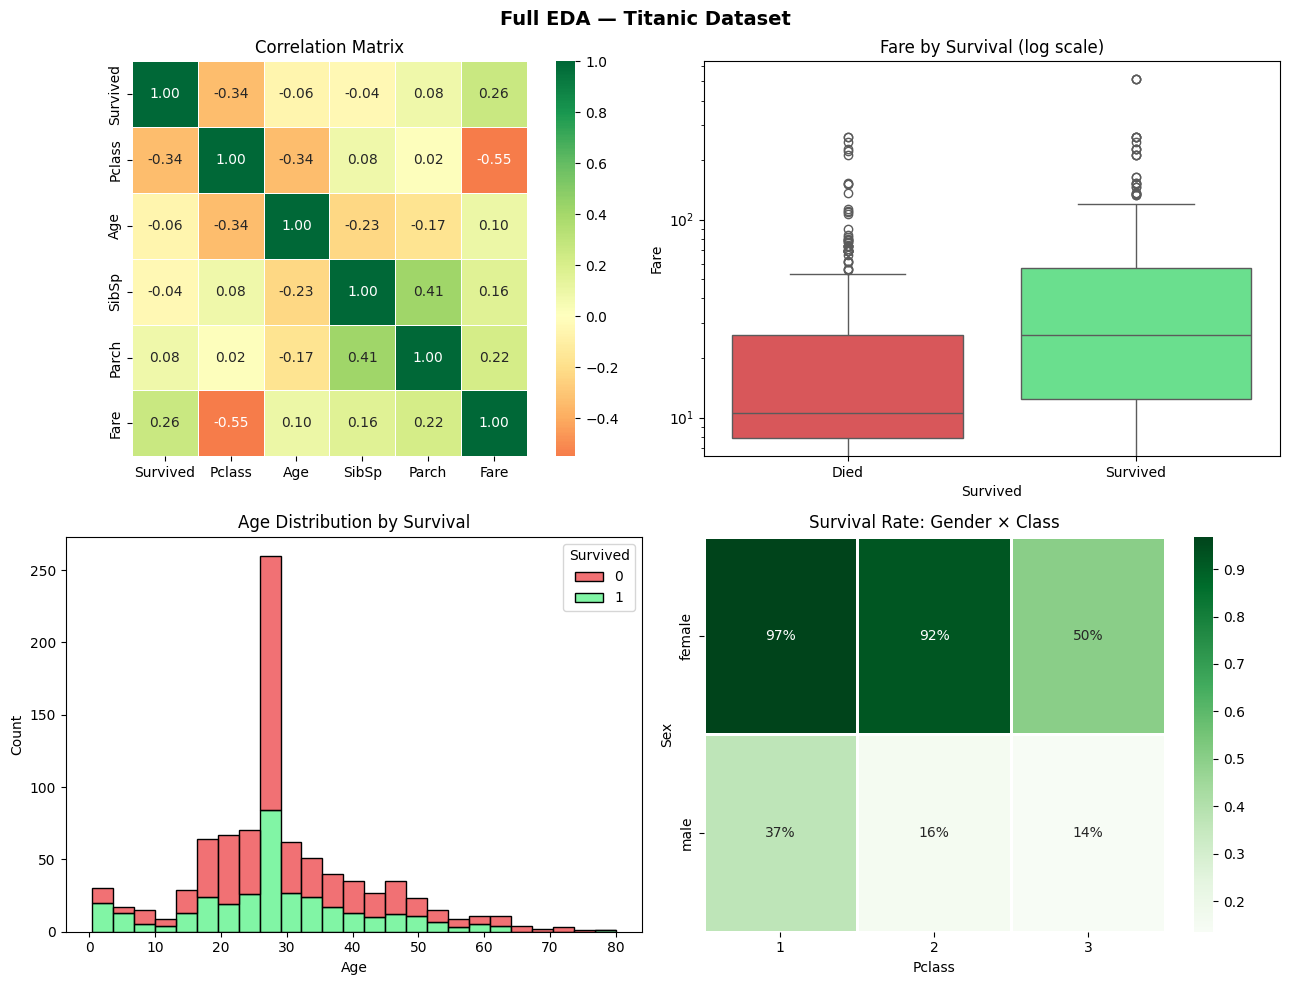


=== KEY FINDINGS ===
Women — 1st class: 97%
Men   — 3rd class: 14%
The interaction tells you more than either feature alone.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic.csv")
df["Age"].fillna(df["Age"].median(), inplace=True)

cols = ["Survived","Pclass","Age","SibSp","Parch","Fare"]
corr = df[cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Full EDA — Titanic Dataset", fontsize=14, fontweight="bold")

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=axes[0,0], square=True, linewidths=0.5)
axes[0,0].set_title("Correlation Matrix")

sns.boxplot(data=df, x="Survived", y="Fare",
            ax=axes[0,1], palette=["#ED4245","#57F287"])
axes[0,1].set_yscale("log")
axes[0,1].set_xticklabels(["Died","Survived"])
axes[0,1].set_title("Fare by Survival (log scale)")

sns.histplot(data=df, x="Age", hue="Survived", multiple="stack",
             ax=axes[1,0], bins=25, palette=["#ED4245","#57F287"])
axes[1,0].set_title("Age Distribution by Survival")

pivot = df.pivot_table(values="Survived", index="Sex", columns="Pclass")
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="Greens",
            ax=axes[1,1], linewidths=1)
axes[1,1].set_title("Survival Rate: Gender × Class")

plt.tight_layout()
plt.savefig("day07_full_eda.png", dpi=150)
plt.show()

print("\n=== KEY FINDINGS ===")
f = df[(df.Sex=="female") & (df.Pclass==1)]["Survived"].mean()
m = df[(df.Sex=="male")   & (df.Pclass==3)]["Survived"].mean()
print(f"Women — 1st class: {f:.0%}")
print(f"Men   — 3rd class: {m:.0%}")
print("The interaction tells you more than either feature alone.")